In [1]:
import pickle
from transformers import pipeline
from pathlib import Path
from collections import defaultdict
from PIL import Image
import numpy as np
from tqdm import tqdm
from videoutils import make_animation
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
train_videos = pickle.load(open("train_structure.pkl", "rb"))
test_videos = pickle.load(open("test_structure.pkl", "rb"))

## ViT 
https://huggingface.co/dima806/crime_cctv_image_detection <br>
**Returns with about 83% accuracy whether is a crime in a CCTV camera image**
<br>
https://huggingface.co/dima806/crime_type_cctv_image_detection <br>
**Returns with about 22% accuracy the type of a crime seen in a CCTV camera image**

In [3]:
pipe1 = pipeline('image-classification', model="dima806/crime_cctv_image_detection", device=0)
pipe2 = pipeline('image-classification', model="dima806/crime_type_cctv_image_detection", device=0)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0
Device set to use mps:0


## 1 prediction for image (by path)

In [4]:
def pipe(image, pipe1, pipe2):
    res1 = pipe1(image)

    crime_score = 0
    for r in res1:
        if r["label"] == "Crime":
            crime_score = r["score"]
            break
    
    if crime_score > 0.5:
        res2 = pipe2(image)
        predicted_label = res2[0]["label"] if len(res2) > 0 else "Unknown"
        return crime_score, predicted_label
    
    return crime_score, "Normal"

In [5]:
frame_path = "Test/RoadAccidents/RoadAccidents004_x264_330.png"
image = Image.open(frame_path)
print(pipe(image, pipe1, pipe2))

(0.9998264908790588, 'RoadAccidents')


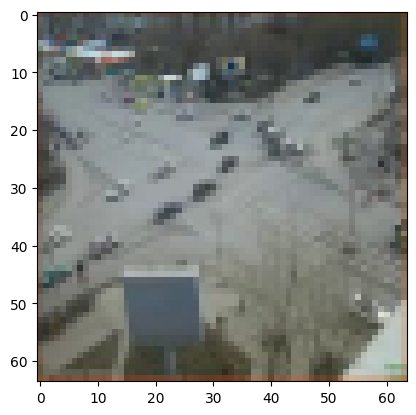

In [6]:
plt.imshow(image)

## Prediction for video

In [7]:
def analyze_video(video_frames, pipe1, pipe2):    
    crime_count = 0
    crimes = {}

    for frame_path in video_frames:
        image = Image.open(frame_path)

        crime_score, label = pipe(image, pipe1, pipe2)

        if crime_score > 0.5:
            crime_count += 1
            crimes[label] = crimes.get(label, 0) + 1

    return crime_count, crimes

In [8]:
frames_list = test_videos["RoadAccidents"]["RoadAccidents004"]["frames"]
crime_count =analyze_video(frames_list, pipe1,pipe2)
crime_count

(39, {'Explosion': 12, 'Shooting': 7, 'RoadAccidents': 20})

In [9]:
max_crime = max(crime_count[1], key=crime_count[1].get)
max_value = crime_count[1][max_crime]
max_crime, max_value

('RoadAccidents', 20)

In [10]:
make_animation(frames_list, 80)